# 01. Last Statement Baseline Model

This notebook develops a baseline model for credit default prediction by using only each customer’s most recent statement. This serves as the starting benchmark for the project and helps assess how well default risk can be predicted from the latest available customer information alone.



In [1]:
import os, gc, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

pd.set_option("display.max_columns", 200)

os.makedirs("/kaggle/working/figures", exist_ok=True)
os.makedirs("/kaggle/working/results", exist_ok=True)

In [2]:
def find_file(filename):
    for dirname, _, filenames in os.walk("/kaggle/input"):
        if filename in filenames:
            return os.path.join(dirname, filename)
    raise FileNotFoundError(f"{filename} not found. Add AMEX datasets to Kaggle input.")

train_path = find_file("train_data_f32.ftr")

print("train_path:", train_path)

train_path: /kaggle/input/datasets/munumbutt/amexfeather/train_data_f32.ftr


In [3]:
def recall_at_top_k(y_true, y_pred_proba, k=0.04):
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred_proba = pd.Series(y_pred_proba).reset_index(drop=True)

    n_top = max(1, int(len(y_pred_proba) * k))
    top_idx = y_pred_proba.sort_values(ascending=False).head(n_top).index

    return y_true.loc[top_idx].sum() / y_true.sum()


def evaluate_model(model_name, y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)

    result = {
        "model": model_name,
        "roc_auc": roc_auc_score(y_true, y_pred_proba),
        "pr_auc": average_precision_score(y_true, y_pred_proba),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "recall_at_top_4pct": recall_at_top_k(y_true, y_pred_proba, k=0.04)
    }

    print(f"Model: {model_name}")
    for k, v in result.items():
        if k != "model":
            print(f"{k}: {v:.6f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report")
    print(classification_report(y_true, y_pred, zero_division=0))

    return result

In [4]:
train = pd.read_feather(train_path)

print("train:", train.shape)

display(train.head())

train: (5531451, 191)


,customer_ID,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,D_42,D_43,D_44,B_4,D_45,B_5,R_2,D_46,D_47,D_48,D_49,B_6,B_7,B_8,D_50,D_51,B_9,R_3,D_52,P_3,B_10,D_53,S_5,B_11,S_6,D_54,R_4,S_7,B_12,S_8,D_55,D_56,B_13,R_5,D_58,S_9,B_14,D_59,D_60,D_61,B_15,S_11,D_62,D_63,D_64,D_65,B_16,B_17,B_18,B_19,D_66,B_20,D_68,S_12,R_6,S_13,B_21,D_69,B_22,D_70,D_71,D_72,S_15,B_23,D_73,P_4,D_74,D_75,D_76,B_24,R_7,D_77,B_25,B_26,D_78,D_79,R_8,R_9,S_16,D_80,R_10,R_11,B_27,D_81,D_82,S_17,R_12,B_28,R_13,D_83,R_14,R_15,D_84,R_16,B_29,B_30,S_18,D_86,D_87,R_17,R_18,D_88,B_31,S_19,R_19,B_32,S_20,R_20,R_21,B_33,D_89,R_22,R_23,D_91,D_92,D_93,D_94,R_24,R_25,D_96,S_22,S_23,S_24,S_25,S_26,D_102,D_103,D_104,D_105,D_106,D_107,B_36,B_37,R_26,R_27,B_38,D_108,D_109,D_110,D_111,B_39,D_112,B_40,S_27,D_113,D_114,D_115,D_116,D_117,D_118,D_119,D_120,D_121,D_122,D_123,D_124,D_125,D_126,D_127,D_128,D_129,B_41,B_42,D_130,D_131,D_132,D_133,R_28,D_134,D_135,D_136,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145,target
0,13914591055249847850,2017-03-09,0.938469,0.001733,0.008724,1.006838,0.009228,0.124035,0.008771,0.004709,NaN,NaN,0.000630,0.080986,0.708906,0.170600,0.006204,0.358587,0.525351,0.255736,NaN,0.063902,0.059416,0.006466,0.148698,1.335856,0.008207,0.001423,0.207334,0.736463,0.096219,NaN,0.023381,0.002768,0.008322,1.001519,0.008298,0.161345,0.148266,0.922998,0.354596,0.152025,0.118075,0.001882,0.158612,0.065728,0.018385,0.063646,0.199617,0.308233,0.016361,0.401619,0.091071,CR,O,0.007126,0.007665,NaN,0.652984,0.008520,NaN,0.004730,6.0,0.272008,0.008363,0.515222,0.002644,0.009013,0.004808,0.008342,0.119403,0.004802,0.108271,0.050882,NaN,0.007554,0.080422,0.069067,NaN,0.004327,0.007562,NaN,0.007729,0.000272,0.001576,0.004239,0.001434,NaN,0.002271,0.004061,0.007121,0.002456,0.002310,0.003532,0.506612,0.008033,1.009825,0.084683,0.003820,0.007043,0.000438,0.006452,0.000830,0.005055,NaN,0.0,0.005720,0.007084,NaN,0.000198,0.008907,NaN,1.0,0.002537,0.005177,0.006626,0.009705,0.007782,0.002450,1.001101,0.002665,0.007479,0.006893,1.503673,1.006133,0.003569,0.008871,0.003950,0.003647,0.004950,0.894090,0.135561,0.911191,0.974539,0.001243,0.766688,1.008691,1.004587,0.893734,NaN,0.670041,0.009968,0.004572,NaN,1.008949,2.0,NaN,0.004326,NaN,NaN,NaN,1.007336,0.210060,0.676922,0.007871,1.0,0.238250,0.0,4.0,0.232120,0.236266,0.0,0.702280,0.434345,0.003057,0.686516,0.008740,1.0,1.003319,1.007819,1.000080,0.006805,NaN,0.002052,0.005972,NaN,0.004345,0.001535,NaN,NaN,NaN,NaN,NaN,0.002427,0.003706,0.003818,NaN,0.000569,0.000610,0.002674,0
1,13914591055249847850,2017-04-07,0.936665,0.005775,0.004923,1.000653,0.006151,0.126750,0.000798,0.002714,NaN,NaN,0.002526,0.069419,0.712795,0.113239,0.006206,0.353630,0.521311,0.223329,NaN,0.065261,0.057744,0.001614,0.149723,1.339794,0.008373,0.001984,0.202778,0.720886,0.099804,NaN,0.030599,0.002749,0.002482,1.009033,0.005136,0.140951,0.143530,0.919414,0.326757,0.156201,0.118737,0.001610,0.148459,0.093935,0.013035,0.065501,0.151387,0.265026,0.017688,0.406326,0.086805,CR,O,0.002413,0.007148,NaN,0.647093,0.002238,NaN,0.003879,6.0,0.188970,0.004030,0.509048,0.004193,0.007842,0.001283,0.006524,0.140611,0.000094,0.101018,0.040469,NaN,0.004832,0.081413,0.074166,NaN,0.004203,0.005304,NaN,0.001864,0.000979,0.009896,0.007597,0.000509,NaN,0.009810,0.000127,0.005966,0.000395,0.001327,0.007773,0.500855,0.000760,1.009461,0.081843,0.000347,0.007789,0.004311,0.002332,0.009469,0.003753,NaN,0.0,0.007584,0.006677,NaN,0.001142,0.005907,NaN,1.0,0.008427,0.008979,0.001854,0.009924,0.005987,0.002247,1.006779,0.002508,0.006827,0.002837,1.503577,1.005791,0.000571,0.000391,0.008351,0.008850,0.003180,0.902135,0.136333,0.919876,0.975625,0.004561,0.786007,1.000084,1.004118,0.906841,NaN,0.668647,0.003921,0.004654,NaN,1.003205,2.0,NaN,0.008707,NaN,NaN,NaN,1.007653,0.184093,0.822281,0.003444,1.0,0.247217,0.0,4.0,0.243532,0.241885,0.0,0.707017,0.430501,0.001306,0.686414,0.000755,1.0,1.008394,1.004333,1.008344,0.004407,NaN,0.001034,0.004838,NaN,0.007495,0.004931,NaN,NaN,NaN,NaN,NaN,0.003954,

In [5]:
train["S_2"] = pd.to_datetime(train["S_2"])

last_statement = (
    train
    .sort_values(["customer_ID", "S_2"])
    .groupby("customer_ID")
    .tail(1)
    .reset_index(drop=True)
)

data = last_statement

print("data:", data.shape)
print("target columns:", [col for col in data.columns if "target" in col])
display(data.head())

del train, last_statement
gc.collect()

data: (458913, 191)
target columns: ['target']


,customer_ID,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,D_42,D_43,D_44,B_4,D_45,B_5,R_2,D_46,D_47,D_48,D_49,B_6,B_7,B_8,D_50,D_51,B_9,R_3,D_52,P_3,B_10,D_53,S_5,B_11,S_6,D_54,R_4,S_7,B_12,S_8,D_55,D_56,B_13,R_5,D_58,S_9,B_14,D_59,D_60,D_61,B_15,S_11,D_62,D_63,D_64,D_65,B_16,B_17,B_18,B_19,D_66,B_20,D_68,S_12,R_6,S_13,B_21,D_69,B_22,D_70,D_71,D_72,S_15,B_23,D_73,P_4,D_74,D_75,D_76,B_24,R_7,D_77,B_25,B_26,D_78,D_79,R_8,R_9,S_16,D_80,R_10,R_11,B_27,D_81,D_82,S_17,R_12,B_28,R_13,D_83,R_14,R_15,D_84,R_16,B_29,B_30,S_18,D_86,D_87,R_17,R_18,D_88,B_31,S_19,R_19,B_32,S_20,R_20,R_21,B_33,D_89,R_22,R_23,D_91,D_92,D_93,D_94,R_24,R_25,D_96,S_22,S_23,S_24,S_25,S_26,D_102,D_103,D_104,D_105,D_106,D_107,B_36,B_37,R_26,R_27,B_38,D_108,D_109,D_110,D_111,B_39,D_112,B_40,S_27,D_113,D_114,D_115,D_116,D_117,D_118,D_119,D_120,D_121,D_122,D_123,D_124,D_125,D_126,D_127,D_128,D_129,B_41,B_42,D_130,D_131,D_132,D_133,R_28,D_134,D_135,D_136,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145,target
0,3249127622875,2018-03-09,1.005004,0.008411,0.005660,1.009403,0.007339,0.179448,0.004560,0.004012,NaN,0.107345,0.004473,0.028382,0.567501,0.008377,0.005527,NaN,0.620382,0.052290,NaN,12.316238,0.039822,0.009782,0.61051,0.009600,0.000983,0.003982,0.547005,NaN,0.227787,NaN,0.000657,0.004535,0.009456,1.001414,0.006539,0.136719,0.012693,0.325218,0.017582,NaN,0.004188,0.005165,0.110490,NaN,0.004538,0.439492,0.003301,0.177977,0.004269,0.688712,0.766742,CO,,0.000217,0.001714,NaN,0.688445,0.008258,NaN,0.004226,NaN,0.186573,0.001372,0.007184,0.003789,NaN,0.006038,0.002012,0.061063,0.009281,0.208271,0.022143,NaN,0.008565,0.075412,0.068575,0.197975,0.009488,0.005415,0.702554,0.002521,0.006449,0.006871,0.001138,0.007095,NaN,0.004269,0.005772,0.008648,0.009095,0.000446,0.000725,NaN,0.006100,1.004292,0.062493,0.001099,NaN,0.003980,0.000840,0.001557,0.001595,NaN,0.0,0.009215,0.000740,NaN,0.005073,0.009798,NaN,1.0,0.008274,0.001175,0.007175,0.009046,0.007305,0.004868,1.006350,0.007810,0.004327,0.001922,0.005907,0.002878,0.007010,0.007857,0.005663,0.003708,0.000416,0.808869,0.136213,0.820041,0.973708,0.001706,0.146715,1.005924,0.961553,0.101347,NaN,0.675922,0.005681,0.010336,NaN,1.005643,2.0,NaN,0.008955,NaN,NaN,NaN,1.008875,0.022305,0.004513,0.006407,1.0,0.509015,0.0,4.0,0.495102,0.495018,1.0,0.618790,1.008003,0.006345,0.187073,0.004136,1.0,1.005272,1.002477,1.004885,0.009960,NaN,0.005780,0.001284,NaN,0.004446,0.006051,NaN,NaN,NaN,NaN,NaN,0.006212,0.003949,0.006435,NaN,0.000439,0.000895,0.006147,0
1,23402014749356,2018-03-24,0.215565,0.030713,0.872928,0.020936,1.002117,0.402358,0.001812,0.851680,NaN,0.985836,0.127954,0.163676,0.083874,0.009859,1.005410,0.457003,0.179752,0.980926,0.043724,0.006228,1.066532,1.002320,NaN,0.005964,0.611416,0.804018,0.071985,0.202145,0.018100,0.149247,0.015220,0.779064,0.005965,1.001578,1.003059,0.301492,0.000660,0.005672,0.866442,NaN,0.014427,0.508735,0.096782,NaN,0.107813,0.485343,0.771255,0.437161,0.009691,0.284268,0.013860,CO,U,0.001422,1.006976,0.887487,0.208136,1.009221,NaN,1.004799,5.0,0.193246,1.123927,0.002410,1.802102,0.002963,0.500007,0.009041,0.001975,0.001711,0.507275,0.887323,NaN,0.003521,0.074493,0.134363,NaN,0.006077,0.656894,NaN,0.178796,0.009590,0.503123,0.509564,0.008165,NaN,0.522143,0.205292,0.006375,0.004102,0.009966,0.002522,NaN,0.003095,1.000615,0.067691,0.034930,0.007965,0.003422,0.004698,0.503102,0.003561,NaN,1.0,0.002515,0.000276,NaN,0.000312,0.007528,NaN,1.0,0.004952,0.008351,0.005291,1.009527,0.000797,1.005920,0.005589,0.000528,0.003837,0.008067,0.008677,0.007267,0.006146,0.006459,0.003881,0.005827,0.003959,1.007346,0.137081,0.991842,0.973369,0.000697,0.251830,1.006782,0.953033,0.393370,0.051353,0.667748,0.003735,0.877445,0.037506,0.013496,7.0,NaN,0.001821,NaN,NaN,NaN,1.001065,0.216212,NaN,0.204857,0.0,0.019726,0.0,-1.0,0.271842,0.270548,1.0,0.290686,0.148469,0.000347,0.142356,1.001241,1.0,0.007674,0.000090,0.009666,0.002824,NaN,1.006926,0.977761,0.028228,0.006798,0.000407,NaN,NaN,NaN,NaN,NaN,0.005257,0.009643,0.008972,NaN,0

0

In [6]:
CAT_COLS = [
    "B_30", "B_38",
    "D_114", "D_116", "D_117", "D_120", "D_126",
    "D_63", "D_64", "D_66", "D_68"
]

def encode_categoricals(df):
    df = df.copy()
    for col in CAT_COLS:
        if col in df.columns:
            df[col] = df[col].astype("category").cat.codes.astype("int16")
    return df

X = data.drop(columns=["customer_ID", "S_2", "target"])
X = encode_categoricals(X)

y = data["target"].astype(int)

print(X.shape)
print(y.value_counts(normalize=True))

(458913, 188)
target
0    0.741066
1    0.258934
Name: proportion, dtype: float64


In [7]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_valid.shape)

(367130, 188)
(91783, 188)


In [8]:
logit_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

logit_model.fit(X_train, y_train)

logit_pred = logit_model.predict_proba(X_valid)[:, 1]

logit_result = evaluate_model(
    "Logistic Regression - Last Statement",
    y_valid,
    logit_pred
)

with open("/kaggle/working/results/01_classification_report_logit.txt", "w") as f:
    f.write(classification_report(
        y_valid,
        (logit_pred >= 0.5).astype(int),
        zero_division=0
    ))

Model: Logistic Regression - Last Statement
roc_auc: 0.956187
pr_auc: 0.885950
precision: 0.717115
recall: 0.903349
f1: 0.799531
recall_at_top_4pct: 0.152571

Confusion Matrix
[[59548  8469]
 [ 2297 21469]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.88      0.92     68017
           1       0.72      0.90      0.80     23766

    accuracy                           0.88     91783
   macro avg       0.84      0.89      0.86     91783
weighted avg       0.90      0.88      0.89     91783



In [9]:
lgbm_model = LGBMClassifier(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    force_col_wise=True,
    verbose=-1
)

lgbm_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="auc"
)

lgbm_pred = lgbm_model.predict_proba(X_valid)[:, 1]

lgbm_result = evaluate_model(
    "LightGBM - Last Statement",
    y_valid,
    lgbm_pred
)

with open("/kaggle/working/results/01_classification_report_lgbm.txt", "w") as f:
    f.write(classification_report(
        y_valid,
        (lgbm_pred >= 0.5).astype(int),
        zero_division=0
    ))

Model: LightGBM - Last Statement
roc_auc: 0.960057
pr_auc: 0.895190
precision: 0.723122
recall: 0.914963
f1: 0.807809
recall_at_top_4pct: 0.153202

Confusion Matrix
[[59691  8326]
 [ 2021 21745]]

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.88      0.92     68017
           1       0.72      0.91      0.81     23766

    accuracy                           0.89     91783
   macro avg       0.85      0.90      0.86     91783
weighted avg       0.90      0.89      0.89     91783



In [10]:
results = pd.DataFrame([logit_result, lgbm_result])
display(results)

results.to_csv("/kaggle/working/results/01_last_statement_results.csv", index=False)

,model,roc_auc,pr_auc,precision,recall,f1,recall_at_top_4pct
0,Logistic Regression - Last Statement,0.956187,0.88595,0.717115,0.903349,0.799531,0.152571
1,LightGBM - Last Statement,0.960057,0.89519,0.723122,0.914963,0.807809,0.153202


,feature,importance
0,P_2,1161
9,D_43,899
5,S_3,854
11,B_4,792
15,D_46,757
1,D_39,701
7,B_3,682
27,P_3,647
16,D_47,584
13,B_5,562


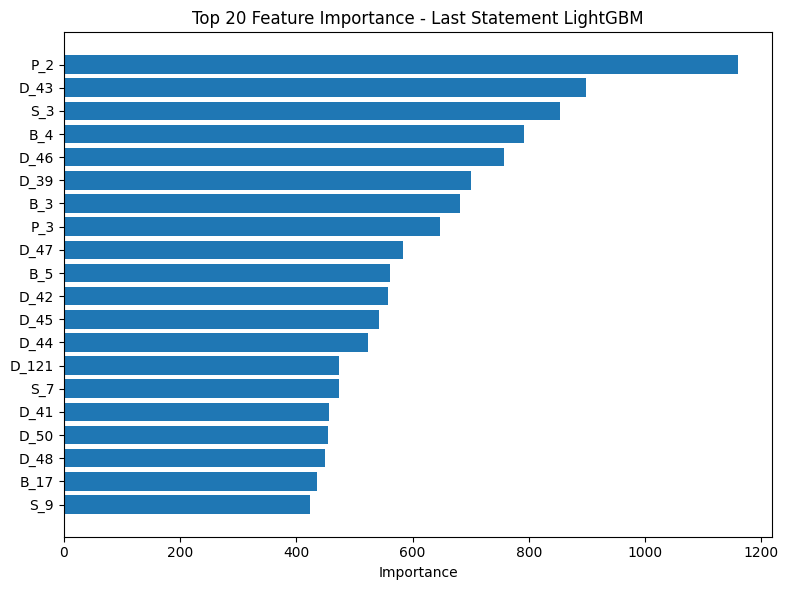

In [11]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgbm_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance.head(20))

importance.to_csv("/kaggle/working/results/01_feature_importance.csv", index=False)

top = importance.head(20).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["importance"])
plt.title("Top 20 Feature Importance - Last Statement LightGBM")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("/kaggle/working/figures/01_feature_importance_last_statement.png", dpi=300)
plt.show()

In [12]:
print("Saved result files:")
print(os.listdir("/kaggle/working/results"))

print("\nSaved figure files:")
print(os.listdir("/kaggle/working/figures"))

Saved result files:
['01_classification_report_lgbm.txt', '01_feature_importance.csv', '01_last_statement_results.csv', '01_classification_report_logit.txt']

Saved figure files:
['01_feature_importance_last_statement.png']


In [13]:
import os

for dirname, _, filenames in os.walk("/kaggle/working/figures"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/working/figures/01_feature_importance_last_statement.png
